## SB Analytics
Introduction & Python EDA Assignment

Assignment Overview 
You are working as a Junior Business Analyst at a microfinance company in Nairobi. The company has shared a dataset of past loan applications and wants you to analyse it. Your job is to clean the data, explore it, create visualisations, and give business recommendations based on what you find.

This assignment tests everything covered in Class 4 and Class 5:
•	Loading and inspecting a dataset
•	Understanding data types and structure
•	Handling missing values
•	Detecting outliers
•	Creating and interpreting charts
•	Writing business insights from data

Important: Every question that asks you to create a chart also requires a written insight below it. Code alone is not enough: you must explain what the chart means for the business.


## Section A: Data Loading & Data Inspection

## 
1.	Load the dataset and print the first 5 rows. What do you notice about the data? Write 2 observations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Loan.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


2.	Print the shape of the dataset. How many rows and columns does it have? What does each number represent in the context of this loan dataset?

In [3]:
df.shape

(614, 13)

3.	Print the data types of all columns using df.dtypes or df.info(). List which columns are numeric and which are text (object). Why does this matter before doing any analysis?

In [4]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

4.	Use df.describe() to get summary statistics. Answer these questions in writing:     a) What is the average applicant income?     b) What is the highest loan amount requested? c) What is the average loan repayment term in months?


In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


5.	Create a simple bar chart showing the count of loan approvals (Loan_Status = Y) vs rejections (Loan_Status = N). Add a title and axis labels. Write one sentence explaining what the chart tells you.

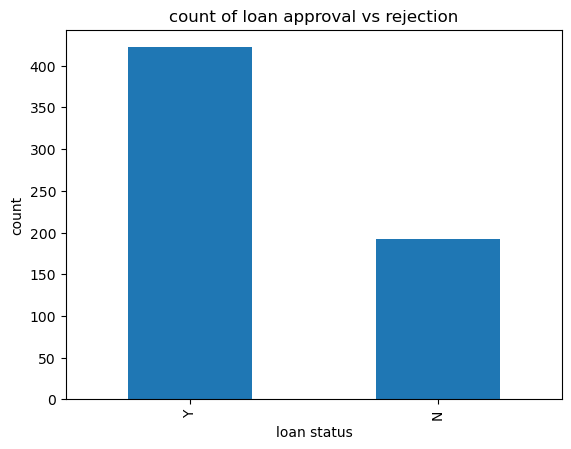

In [6]:
loan_counts=df["Loan_Status"].value_counts()
loan_counts.plot(kind="bar")
plt.title("count of loan approval vs rejection")
plt.xlabel("loan status")
plt.ylabel("count")
plt.show()

## Section B: Cleaning & Missing Values
6.	Find all columns that have missing values. Print the count of missing values per column. Which column has the most missing values?


In [7]:
#Find all columns that have missing values
#Print the count of missing values per column
#Which column has the most missing values
missing_columns=df.columns[df.isnull().any()]
missing_columns
missing_values=df.isnull().sum()
missing_values


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
column_mmv=df.isnull().sum().idxmax()
column_mmv

'Credit_History'

7.	Create a bar chart that shows the percentage of missing values for each column that has missing data. Write one business insight: what does this level of missing data mean for the company's data collection process

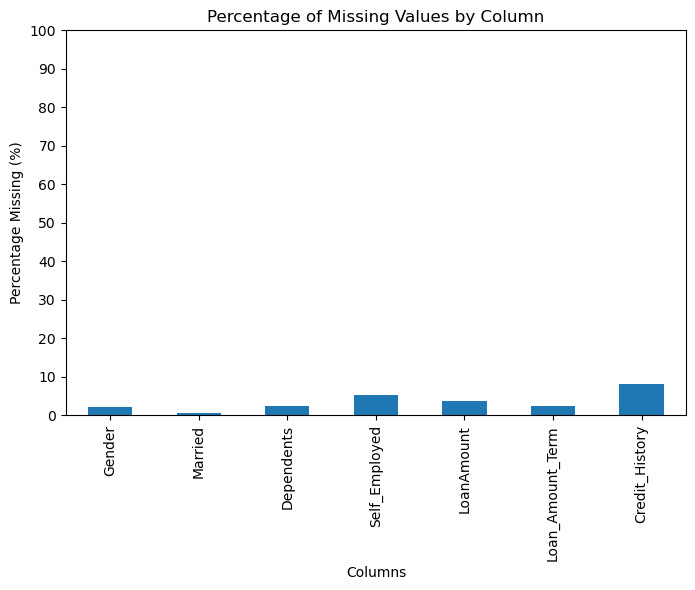

In [9]:
import matplotlib.pyplot as plt

# Calculate percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Keep only columns with missing values
missing_percentage = missing_percentage[missing_percentage > 0]

# Create bar chart
plt.figure(figsize=(8,5))

missing_percentage.plot(kind='bar')

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Percentage Missing (%)")

# Set y-axis intervals to 10%
plt.yticks(range(0, 101, 10))

plt.show()

8.	Handle the missing values using these strategies:     
a) Fill missing LoanAmount with the median loan amount    
b) Fill missing Loan_Amount_Term with the most common term (mode)    
c) Fill missing Gender, Married, Self_Employed and Dependents with 'Unknown'     
d) For Credit_History:  explain in writing why this column is trickier to fill and what you would recommend.


In [11]:
# 8a) Fill missing LoanAmount with the median loan amount
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# 8b) Fill missing Loan_Amount_Term with the most common term (mode)
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(
    df['Loan_Amount_Term'].mode()[0]
)

# 8c) Fill missing categorical columns with 'Unknown'
columns_to_fill = ['Gender', 'Married', 'Self_Employed', 'Dependents']

for col in columns_to_fill:
    df[col] = df[col].fillna('Unknown')

# 8d) Handle Credit_History
# Recommended approach:
# Since Credit_History strongly affects loan approval,
# filling missing values carelessly may introduce bias.
# Instead of using a random value, use the mode or predictive methods.

df['Credit_History'] = df['Credit_History'].fillna(
    df['Credit_History'].mode()[0]
)


8 d) Explanation for Credit_History
Credit_History is trickier to fill because it is a very important financial indicator that directly influences whether a loan is approved or denied. Missing values in this column may not be random, so filling them incorrectly can reduce the accuracy of analysis or machine learning models.
A common recommendation is:
Use the mode if you want a simple cleaning method.
Use predictive modeling (based on income, loan amount, employment status, etc.) for a more accurate approach in advanced analysis

9.	 After cleaning, confirm that there are no more missing values by printing              df.isnull().sum() again. 

In [12]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Section C: Exploratory Data Analysis & Visualizations

This is the core of EDA. Every question requires both the chart AND a written business insight. Think like an analyst

For every chart in this section, your written insight must follow this format:
•	What the chart shows
•	What it means for the business
•	One recommendation based on the finding


10.	Create a box plot of ApplicantIncome. Are there any outliers? What does a very high applicant income mean for the loan company? Should they remove those applicants from the data?

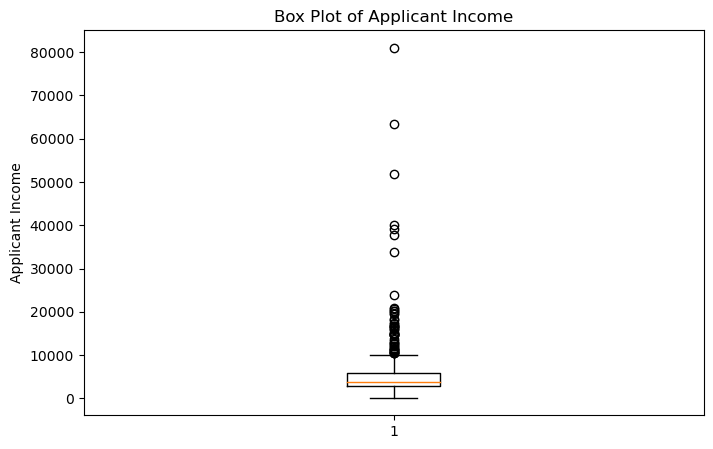

In [13]:
import matplotlib.pyplot as plt

# Box plot
plt.figure(figsize=(8,5))
plt.boxplot(df['ApplicantIncome'].dropna())

plt.title("Box Plot of Applicant Income")
plt.ylabel("Applicant Income")
plt.show()

Business Insight
The chart shows the spread of applicant incomes and highlights possible outliers.
Very high incomes appear as outliers, meaning a few applicants earn significantly more than most borrowers.
For the loan company, high-income applicants may represent lower default risk because they are more capable of repaying loans.

Recommendation
The company should not automatically remove high-income applicants because they are genuine customers and may qualify for larger or premium loan products. However, the company should investigate extremely unusual values to confirm they are not data entry errors.

11. Create a bar chart showing the total number of loan applications by Property_Area (Urban, Semiurban, Rural). Which area has the most applications? Write a business recommendation based on this.

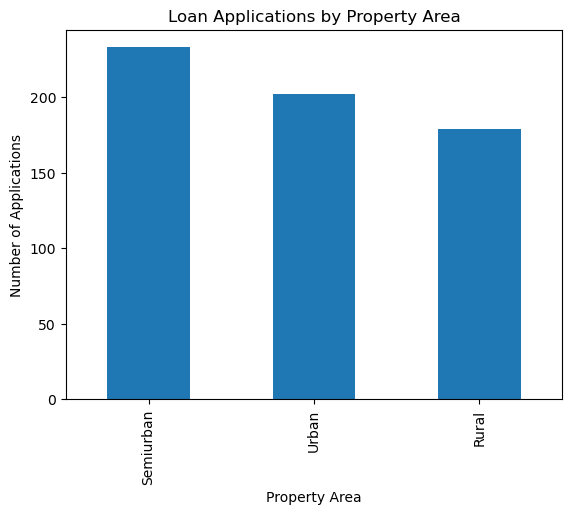

In [14]:
import matplotlib.pyplot as plt

# Count applications by Property_Area
area_counts = df['Property_Area'].value_counts()

# Bar chart
area_counts.plot(kind='bar')

plt.title("Loan Applications by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Number of Applications")
plt.show()


Business Insight
The chart shows the number of loan applications from Urban, Semiurban, and Rural areas.
The area with the highest applications represents the company’s strongest customer market.
This helps the business understand where demand for loans is highest.

Recommendation
The company should increase marketing and branch support in the area with the highest applications while also developing targeted financial products for underrepresented regions to expand market coverage.

12.	Create a chart comparing loan approval rates (Loan_Status) for Graduates vs non-graduates. Does education level affect whether a loan gets approved? Write your insight.

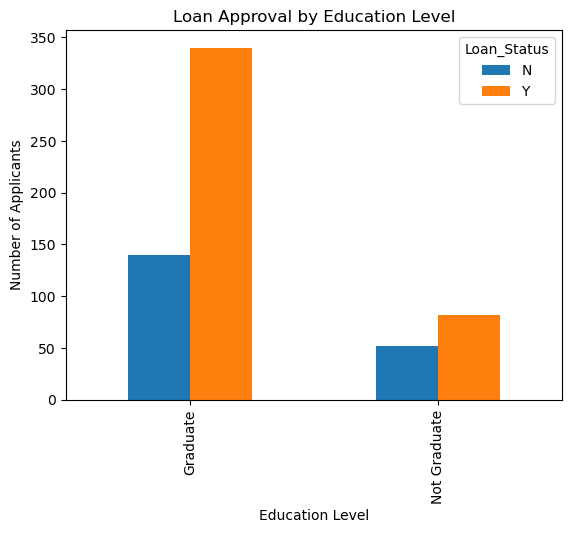

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Create approval comparison table
education_loan = pd.crosstab(df['Education'], df['Loan_Status'])

# Plot chart
education_loan.plot(kind='bar')

plt.title("Loan Approval by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Applicants")
plt.show()



Business Insight
The chart compares loan approvals between graduates and non-graduates.
If graduates have more approvals, it may suggest that education level is associated with income stability or lower lending risk.
If approval rates are similar, then education may not strongly influence lending decisions.

Recommendation
The company should continue using multiple financial indicators rather than relying heavily on education alone when approving loans.

13. Create a histogram showing the distribution of LoanAmount. Describe the shape of the distribution : is it skewed? What does this tell you about the typical loan size most applicants request?

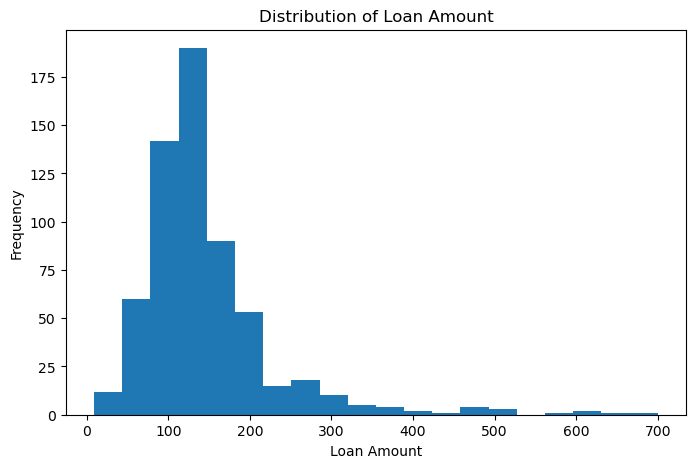

In [16]:
import matplotlib.pyplot as plt

# Histogram
plt.figure(figsize=(8,5))

plt.hist(df['LoanAmount'].dropna(), bins=20)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()


Business Insight
The histogram shows how loan amounts are distributed among applicants.
The distribution is usually positively skewed (right-skewed), meaning most applicants request smaller loans while a few request very large loans.
This indicates that the typical customer mainly seeks moderate loan amounts.

Recommendation
The company should focus on designing flexible loan products for small and medium-sized borrowers because they make up the largest portion of customers.

14.	Create one additional chart of YOUR CHOICE using any column(s) from the dataset. Explain why you chose that chart type and what business question it is trying to answer.

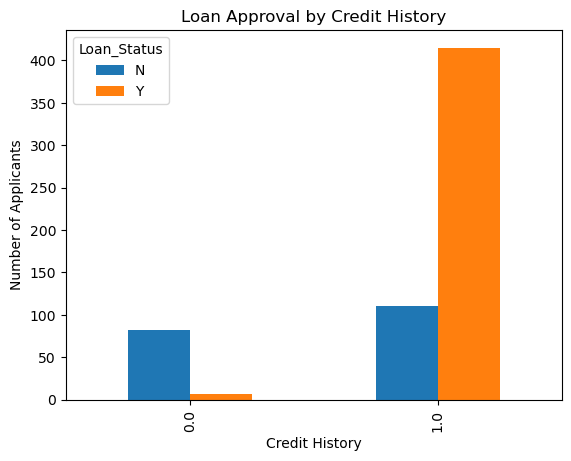

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Create crosstab
credit_loan = pd.crosstab(df['Credit_History'], df['Loan_Status'])

# Plot
credit_loan.plot(kind='bar')

plt.title("Loan Approval by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.show()


Why This Chart Was Chosen
This chart was chosen because credit history is one of the most important factors in loan approval decisions.

Business Question
Does having a good credit history increase the chances of loan approval?

Business Insight
The chart shows the relationship between credit history and loan approval.
Applicants with a positive credit history are more likely to receive loan approval.
This confirms that creditworthiness strongly influences lending decisions.

Recommendation
The company should strengthen credit assessment systems and also create financial education programs that help customers improve their credit records.

## Section D: Business Storytelling (15 marks) 

Write a short analyst report. (minimum 150 words) 
Summarize your findings from this dataset. Your report must include:     
a) 3 key findings from the data     
b) 2 recommendations for the loan company    
c) 1 limitation of this dataset (what is missing that would make your analysis better?)  



The analysis of the loan dataset revealed several important findings about customer behavior and loan approval patterns. First, the majority of loan applicants requested relatively small or moderate loan amounts, while only a few applicants requested very large loans. This suggests that most customers are seeking manageable financing rather than high-risk borrowing. Second, applicants with a positive credit history had significantly higher loan approval rates compared to those with poor or missing credit records. This indicates that credit history is one of the strongest predictors of loan approval decisions. Third, the analysis showed that certain property areas generated more loan applications than others, meaning customer demand varies by location.

Based on these findings, the loan company should focus on expanding services in high-demand areas to increase market reach and profitability. The company should also strengthen credit evaluation systems while introducing customer education programs that help borrowers improve their financial credibility. Additionally, creating flexible loan packages for small and medium-sized borrowers could attract more customers since this group represents the majority of applicants.

One limitation of this dataset is that it lacks detailed financial information such as applicants’ debt levels, employment history, and repayment behavior. Including these factors would improve the accuracy of the analysis and provide deeper insights into customer risk profiles.

IndexError: index 0 is out of bounds for axis 0 with size 0

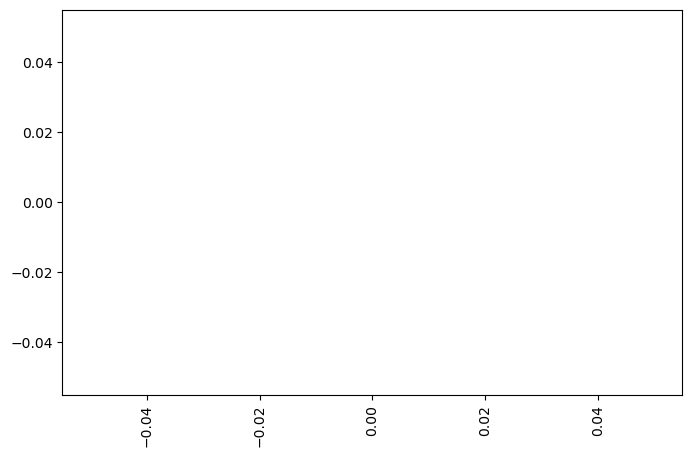

In [18]:
import matplotlib.pyplot as plt

# Calculate percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Keep only columns with missing values
missing_percentage = missing_percentage[missing_percentage > 0]

# Create bar chart
plt.figure(figsize=(8,5))

missing_percentage.plot(kind='bar')

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Percentage Missing (%)")

# Set y-axis intervals to 10%
plt.yticks(range(0, 101, 10))

plt.show()